In [ ]:
import numpy as np
import h5py
import time

from matplotlib import pyplot as plt
from simulation import *
from qtransform import *
from gw_class_gen import *
from config import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
def make_tdi_dict(X, Y, Z):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        psd_data = np.load(f'{psd_path}psd_{name}.npz')
        f_psd, psd = psd_data['f_psd'], psd_data['psd']
        tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd)
    return tdi_dict

In [3]:
gw_dataset_path = '../dist/gw_dataset_2.h5'

with h5py.File(gw_dataset_path, "r") as h5:
    X_array = h5["X"][:]       # shape (N, 512, 512)
    Y_array = h5["Y"][:]       # shape (N, 512, 512)
    Z_array = h5["Z"][:]       # shape (N, 512, 512)
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]
    spin1_array = h5["spin1"][:]
    spin2_array = h5["spin2"][:]
    gw_beta_array = h5["gw_beta"][:]
    gw_lambda_array = h5["gw_lambda"][:]

In [10]:
index = 2  # Change this index to visualize different samples
m1 = m1_array[index]
m2 = m2_array[index]
d = d_array[index]
spin1 = spin1_array[index]
spin2 = spin2_array[index]
gw_beta = gw_beta_array[index]
gw_lambda = gw_lambda_array[index]

pipe = {'t0': 10368000, 'dt': 0.25,'size': 10 * 3600 / 0.25,
            't_inj': 5 * 3600}

gws = [{'type': 'BinaryInspiralGW', 'm1': m1, 'm2': m2, 'd': d,
        'spin1': spin1, 'spin2': spin2, 't_inj': pipe['t_inj'], 'domain': 'freq'}]

tdi_dict = make_tdi_dict(X_array[index], Y_array[index], Z_array[index])

specs = {'low_mass': {'trange':(-4, 1), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'mid_mass': {'trange':(-4, 1), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'high_mass': {'trange':(-4, 2), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}

chirp = chirp_mass(m1, m2)

if chirp < 1e5:
    spec = specs['low_mass']
elif chirp < 1e6:
    spec = specs['mid_mass']
else:
    spec = specs['high_mass']

In [17]:
event = gws[0]
channel = 'T'
res = 512

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

4.144977807998657


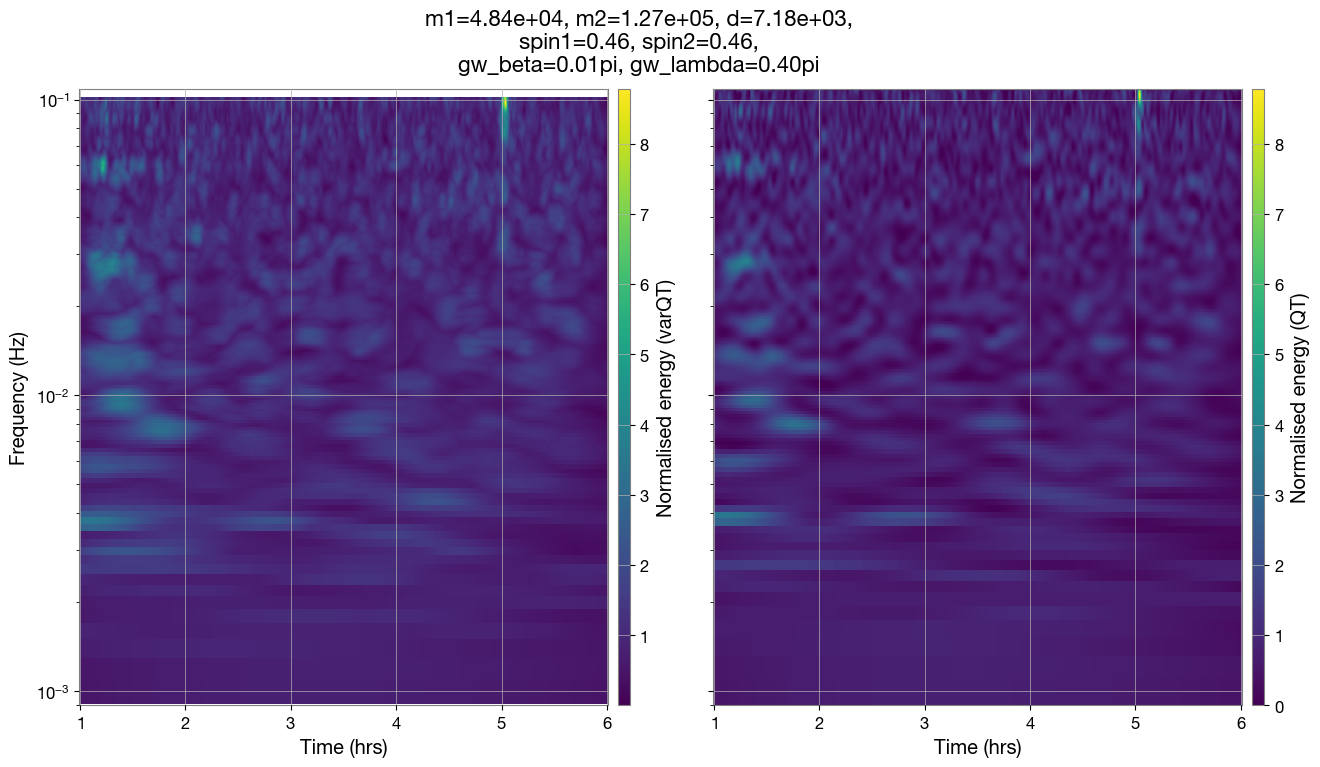

In [18]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
title = f'm1={m1:.2e}, m2={m2:.2e}, d={d:.2e}, \n' +\
    f'spin1={spin1:.2f}, spin2={spin2:.2f}, \n' +\
    f'gw_beta={gw_beta/np.pi:.2f}pi, gw_lambda={gw_lambda/np.pi:.2f}pi \n'
fig.suptitle(title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()